In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
canonical_df = pd.read_pickle(
    "/content/drive/MyDrive/router_project_canonical.pkl"
)

splits = np.load(
    "/content/drive/MyDrive/router_split_indices.npz"
)

distilbert_test_pred = np.load(
    "/content/drive/MyDrive/distilbert_test_predictions.npy"
)

distilbert_test_choices = np.load(
    "/content/drive/MyDrive/distilbert_test_choices.npy"
)

FINAL_THRESHOLD = float(
    np.load(
        "/content/drive/MyDrive/distilbert_final_threshold.npy"
    )[0]
)

train_idx = splits["train_idx"]
test_idx = splits["test_idx"]

print("Dataset:", canonical_df.shape)
print("Test predictions:", distilbert_test_pred.shape)
print("Test choices:", distilbert_test_choices.shape)
print("Frozen threshold:", FINAL_THRESHOLD)

Dataset: (22962, 26)
Test predictions: (2297, 11)
Test choices: (2297,)
Frozen threshold: 0.94


In [3]:
MODEL_COLS = [
    "WizardLM/WizardLM-13B-V1.2",
    "claude-instant-v1",
    "claude-v1",
    "claude-v2",
    "gpt-3.5-turbo-1106",
    "gpt-4-1106-preview",
    "meta/code-llama-instruct-34b-chat",
    "meta/llama-2-70b-chat",
    "mistralai/mistral-7b-chat",
    "mistralai/mixtral-8x7b-chat",
    "zero-one-ai/Yi-34B-Chat"
]

X = canonical_df[
    ["sample_id", "prompt", "domain", "eval_name"]
].copy()

Y = pd.DataFrame({
    model: canonical_df[f"{model}|performance"]
    for model in MODEL_COLS
})

C = pd.DataFrame({
    model: canonical_df[f"{model}|cost"]
    for model in MODEL_COLS
})

X_test = X.iloc[test_idx].reset_index(drop=True)
Y_test = Y.iloc[test_idx].reset_index(drop=True)
C_test = C.iloc[test_idx].reset_index(drop=True)

Y_train = Y.iloc[train_idx].reset_index(drop=True)
C_train = C.iloc[train_idx].reset_index(drop=True)

print(X_test.shape)
print(Y_test.shape)
print(C_test.shape)

(2297, 4)
(2297, 11)
(2297, 11)


In [4]:
vectorizer = joblib.load(
    "/content/drive/MyDrive/router_tfidf_vectorizer.joblib"
)

ridge = joblib.load(
    "/content/drive/MyDrive/router_ridge_baseline.joblib"
)

TFIDF_THRESHOLD = float(
    np.load(
        "/content/drive/MyDrive/router_selected_tfidf_threshold.npy"
    )[0]
)

print("TF-IDF threshold:", TFIDF_THRESHOLD)

TF-IDF threshold: 0.9500000000000003


In [6]:
mean_train_cost = C_train.mean().to_numpy()

def route_predictions(
    predictions,
    model_costs,
    threshold
):
    choices = []

    cost_order = np.argsort(model_costs)

    for scores in predictions:

        eligible = [
            k
            for k in cost_order
            if scores[k] >= threshold
        ]

        if eligible:
            selected = eligible[0]
        else:
            selected = int(np.argmax(scores))

        choices.append(selected)

    return np.array(choices)

In [9]:
import numpy as np
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge


# --------------------------------------------------
# 1. Recreate TRAIN data using the original split
# --------------------------------------------------

X_train = X.iloc[
    train_idx
].reset_index(drop=True)

Y_train = Y.iloc[
    train_idx
].reset_index(drop=True)


print("Train X:", X_train.shape)
print("Train Y:", Y_train.shape)


# --------------------------------------------------
# 2. Recreate the EXACT SAME TF-IDF configuration
# --------------------------------------------------

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)


# IMPORTANT:
# Fit ONLY on training data
X_train_tfidf = vectorizer.fit_transform(
    X_train["prompt"]
)


print(
    "Training TF-IDF matrix:",
    X_train_tfidf.shape
)


# --------------------------------------------------
# 3. Recreate the EXACT SAME Ridge baseline
# --------------------------------------------------

ridge = Ridge(
    alpha=1.0
)

ridge.fit(
    X_train_tfidf,
    Y_train
)

print("Ridge model fitted successfully.")


# --------------------------------------------------
# 4. Transform TEST data
# --------------------------------------------------

X_test_tfidf = vectorizer.transform(
    X_test["prompt"]
)

print(
    "Test TF-IDF matrix:",
    X_test_tfidf.shape
)


# --------------------------------------------------
# 5. Predict TEST performance
# --------------------------------------------------

tfidf_test_pred = ridge.predict(
    X_test_tfidf
)

tfidf_test_pred = np.clip(
    tfidf_test_pred,
    0.0,
    1.0
)

print(
    "Prediction shape:",
    tfidf_test_pred.shape
)

print(
    "Prediction range:",
    tfidf_test_pred.min(),
    "to",
    tfidf_test_pred.max()
)


# --------------------------------------------------
# 6. Save CORRECT fitted artifacts
# --------------------------------------------------

joblib.dump(
    vectorizer,
    "/content/drive/MyDrive/router_tfidf_vectorizer.joblib"
)

joblib.dump(
    ridge,
    "/content/drive/MyDrive/router_ridge_baseline.joblib"
)

print(
    "Correct fitted TF-IDF and Ridge artifacts saved."
)

Train X: (18369, 4)
Train Y: (18369, 11)
Training TF-IDF matrix: (18369, 30000)
Ridge model fitted successfully.
Test TF-IDF matrix: (2297, 30000)
Prediction shape: (2297, 11)
Prediction range: 0.0 to 1.0
Correct fitted TF-IDF and Ridge artifacts saved.


In [10]:
mean_train_cost = C_train.mean().to_numpy()

TFIDF_THRESHOLD = float(
    np.load(
        "/content/drive/MyDrive/"
        "router_selected_tfidf_threshold.npy"
    )[0]
)

def route_predictions(
    predictions,
    model_costs,
    threshold
):

    choices = []

    cost_order = np.argsort(
        model_costs
    )

    for scores in predictions:

        eligible = [
            k
            for k in cost_order
            if scores[k] >= threshold
        ]

        if len(eligible) > 0:
            selected = eligible[0]
        else:
            selected = int(
                np.argmax(scores)
            )

        choices.append(selected)

    return np.array(choices)


tfidf_test_choices = route_predictions(
    tfidf_test_pred,
    mean_train_cost,
    TFIDF_THRESHOLD
)

rows = np.arange(
    len(tfidf_test_choices)
)

Y_test_np = Y_test.to_numpy()
C_test_np = C_test.to_numpy()

tfidf_test_performance = Y_test_np[
    rows,
    tfidf_test_choices
]

tfidf_test_cost = C_test_np[
    rows,
    tfidf_test_choices
]

print(
    "===== TF-IDF FINAL TEST RESULT ====="
)

print(
    "Mean performance:",
    tfidf_test_performance.mean()
)

print(
    "Mean cost:",
    tfidf_test_cost.mean()
)

===== TF-IDF FINAL TEST RESULT =====
Mean performance: 0.733239
Mean cost: 0.002181323


In [11]:
distilbert_performance = Y_test_np[
    rows,
    distilbert_test_choices
]

distilbert_cost = C_test_np[
    rows,
    distilbert_test_choices
]

print(
    "DistilBERT performance:",
    distilbert_performance.mean()
)

print(
    "DistilBERT cost:",
    distilbert_cost.mean()
)

DistilBERT performance: 0.7604484
DistilBERT cost: 0.0028767393


In [12]:
BEST_FIXED_MODEL = "gpt-4-1106-preview"
CHEAPEST_FIXED_MODEL = "mistralai/mistral-7b-chat"

gpt4_performance = Y_test[
    BEST_FIXED_MODEL
].to_numpy()

gpt4_cost = C_test[
    BEST_FIXED_MODEL
].to_numpy()

cheapest_performance = Y_test[
    CHEAPEST_FIXED_MODEL
].to_numpy()

cheapest_cost = C_test[
    CHEAPEST_FIXED_MODEL
].to_numpy()

In [13]:
oracle_performance = []
oracle_cost = []
oracle_choices = []

for i in range(len(Y_test_np)):

    scores = Y_test_np[i]
    costs = C_test_np[i]

    best_score = scores.max()

    candidates = np.where(
        scores == best_score
    )[0]

    selected = candidates[
        np.argmin(costs[candidates])
    ]

    oracle_choices.append(selected)
    oracle_performance.append(
        scores[selected]
    )
    oracle_cost.append(
        costs[selected]
    )

oracle_performance = np.array(
    oracle_performance
)

oracle_cost = np.array(
    oracle_cost
)

oracle_choices = np.array(
    oracle_choices
)

In [14]:
final_systems = pd.DataFrame([
    {
        "System": "Cheapest Fixed",
        "Performance":
            cheapest_performance.mean(),
        "Cost":
            cheapest_cost.mean()
    },
    {
        "System": "TF-IDF Router",
        "Performance":
            tfidf_test_performance.mean(),
        "Cost":
            tfidf_test_cost.mean()
    },
    {
        "System": "DistilBERT Router",
        "Performance":
            distilbert_performance.mean(),
        "Cost":
            distilbert_cost.mean()
    },
    {
        "System": "GPT-4 Fixed",
        "Performance":
            gpt4_performance.mean(),
        "Cost":
            gpt4_cost.mean()
    },
    {
        "System": "Oracle",
        "Performance":
            oracle_performance.mean(),
        "Cost":
            oracle_cost.mean()
    }
])

display(final_systems)

,System,Performance,Cost
0,Cheapest Fixed,0.322704,0.000049
1,TF-IDF Router,0.733239,0.002181
2,DistilBERT Router,0.760448,0.002877
3,GPT-4 Fixed,0.768067,0.003738
4,Oracle,0.888659,0.000263


In [15]:
final_systems.to_csv(
    "/content/drive/MyDrive/"
    "final_all_systems_test.csv",
    index=False
)

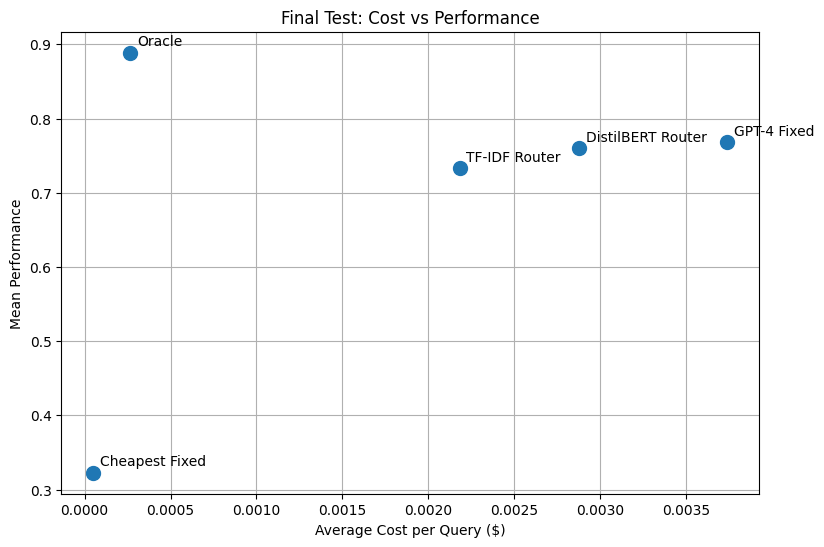

In [16]:
plt.figure(figsize=(9, 6))

plt.scatter(
    final_systems["Cost"],
    final_systems["Performance"],
    s=100
)

for _, row in final_systems.iterrows():

    plt.annotate(
        row["System"],
        (
            row["Cost"],
            row["Performance"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Cost per Query ($)")
plt.ylabel("Mean Performance")
plt.title(
    "Final Test: Cost vs Performance"
)

plt.grid(True)

plt.savefig(
    "/content/drive/MyDrive/"
    "final_cost_vs_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [17]:
selection_counts = np.bincount(
    distilbert_test_choices,
    minlength=len(MODEL_COLS)
)

selection_df = pd.DataFrame({
    "model": MODEL_COLS,
    "selected_count": selection_counts
})

selection_df["selected_percent"] = (
    100
    * selection_df["selected_count"]
    / len(X_test)
)

selection_df = selection_df.sort_values(
    "selected_count",
    ascending=False
)

display(selection_df)

,model,selected_count,selected_percent
5,gpt-4-1106-preview,1340,58.336961
3,claude-v2,454,19.764911
9,mistralai/mixtral-8x7b-chat,212,9.229430
2,claude-v1,154,6.704397
10,zero-one-ai/Yi-34B-Chat,99,4.309970
4,gpt-3.5-turbo-1106,22,0.957771
1,claude-instant-v1,16,0.696561
0,WizardLM/WizardLM-13B-V1.2,0,0.000000
6,meta/code-llama-instruct-34b-chat,0,0.000000
8,mistralai/mistral-7b-chat,0,0.000000


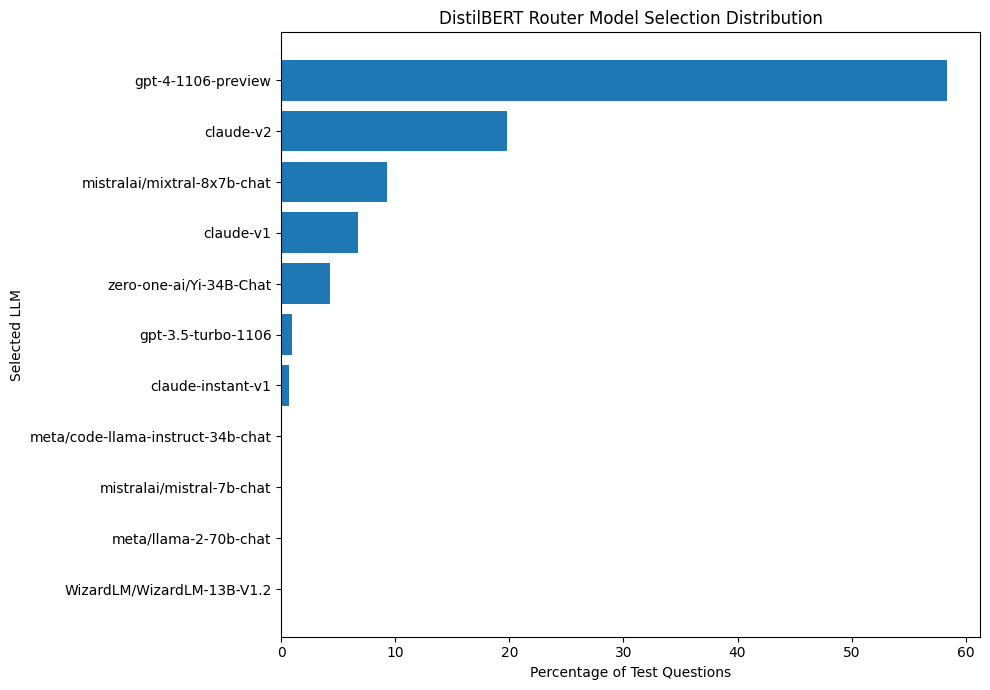

In [18]:
plot_df = selection_df.sort_values(
    "selected_percent",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["model"],
    plot_df["selected_percent"]
)

plt.xlabel("Percentage of Test Questions")
plt.ylabel("Selected LLM")

plt.title(
    "DistilBERT Router Model Selection Distribution"
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/"
    "router_model_selection.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [19]:
domain_results = []

for domain in [
    "MMLU",
    "ARC",
    "GSM8K"
]:

    mask = (
        X_test["domain"].to_numpy()
        == domain
    )

    domain_results.append({
        "domain": domain,

        "questions":
            mask.sum(),

        "router_performance":
            distilbert_performance[
                mask
            ].mean(),

        "router_cost":
            distilbert_cost[
                mask
            ].mean(),

        "gpt4_performance":
            gpt4_performance[
                mask
            ].mean(),

        "gpt4_cost":
            gpt4_cost[
                mask
            ].mean(),

        "oracle_performance":
            oracle_performance[
                mask
            ].mean()
    })

domain_df = pd.DataFrame(
    domain_results
)

display(domain_df)

,domain,questions,router_performance,router_cost,gpt4_performance,gpt4_cost,oracle_performance
0,MMLU,1405,0.795018,0.001181,0.804270,0.001439,0.951601
1,ARC,147,0.952381,0.000595,0.965986,0.000873,0.993197
2,GSM8K,745,0.657383,0.006524,0.660738,0.008640,0.749329


In [20]:
domain_df[
    "performance_gap_pp"
] = (
    domain_df["gpt4_performance"]
    -
    domain_df["router_performance"]
) * 100

domain_df[
    "cost_saving_percent"
] = (
    1
    -
    domain_df["router_cost"]
    /
    domain_df["gpt4_cost"]
) * 100

display(domain_df)

,domain,questions,router_performance,router_cost,gpt4_performance,gpt4_cost,oracle_performance,performance_gap_pp,cost_saving_percent
0,MMLU,1405,0.795018,0.001181,0.804270,0.001439,0.951601,0.925267,17.893303
1,ARC,147,0.952381,0.000595,0.965986,0.000873,0.993197,1.360542,31.860733
2,GSM8K,745,0.657383,0.006524,0.660738,0.008640,0.749329,0.335568,24.488962


In [21]:
domain_df.to_csv(
    "/content/drive/MyDrive/"
    "final_domain_results.csv",
    index=False
)

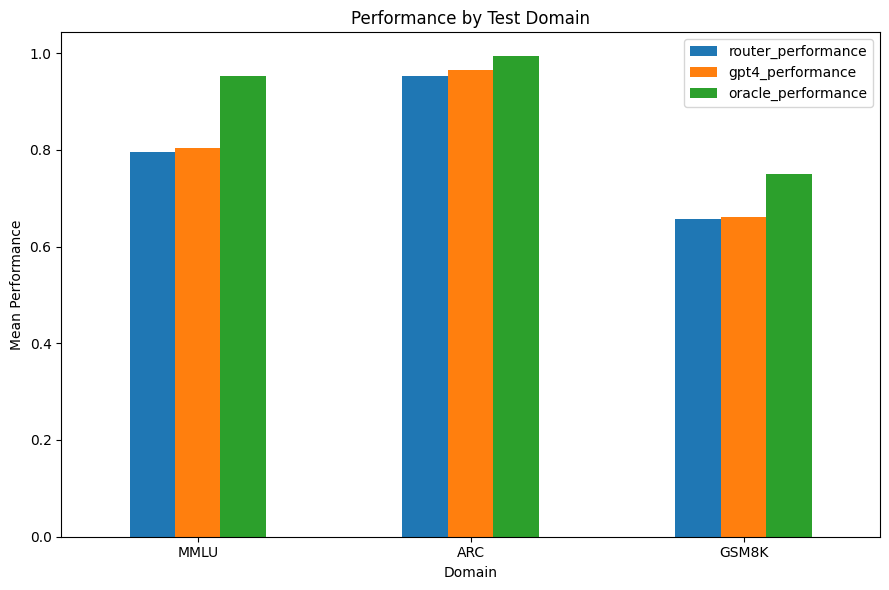

In [22]:
domain_plot = domain_df.set_index(
    "domain"
)[
    [
        "router_performance",
        "gpt4_performance",
        "oracle_performance"
    ]
]

domain_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylabel("Mean Performance")
plt.xlabel("Domain")

plt.title(
    "Performance by Test Domain"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/"
    "domain_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [23]:
difference_vs_gpt4 = (
    distilbert_performance
    -
    gpt4_performance
)

print(
    "Router better than GPT-4:",
    (difference_vs_gpt4 > 0).sum()
)

print(
    "Same performance:",
    (difference_vs_gpt4 == 0).sum()
)

print(
    "Router worse than GPT-4:",
    (difference_vs_gpt4 < 0).sum()
)

Router better than GPT-4: 117
Same performance: 2063
Router worse than GPT-4: 117


In [24]:
print(
    "Better:",
    round(
        100 *
        (difference_vs_gpt4 > 0).mean(),
        2
    ),
    "%"
)

print(
    "Same:",
    round(
        100 *
        (difference_vs_gpt4 == 0).mean(),
        2
    ),
    "%"
)

print(
    "Worse:",
    round(
        100 *
        (difference_vs_gpt4 < 0).mean(),
        2
    ),
    "%"
)

Better: 5.09 %
Same: 89.81 %
Worse: 5.09 %


In [25]:
selected_model_names = [
    MODEL_COLS[i]
    for i in distilbert_test_choices
]

analysis_df = X_test.copy()

analysis_df[
    "selected_model"
] = selected_model_names

analysis_df[
    "router_performance"
] = distilbert_performance

analysis_df[
    "gpt4_performance"
] = gpt4_performance

analysis_df[
    "performance_difference"
] = (
    distilbert_performance
    -
    gpt4_performance
)

analysis_df[
    "router_cost"
] = distilbert_cost

analysis_df[
    "gpt4_cost"
] = gpt4_cost

analysis_df[
    "cost_saved"
] = (
    gpt4_cost
    -
    distilbert_cost
)

analysis_df[
    "prompt_preview"
] = analysis_df[
    "prompt"
].str[:300]

In [26]:
success_examples = analysis_df[
    (
        analysis_df["cost_saved"] > 0
    )
    &
    (
        analysis_df[
            "performance_difference"
        ] >= 0
    )
].sort_values(
    "cost_saved",
    ascending=False
)

display(
    success_examples[
        [
            "domain",
            "prompt_preview",
            "selected_model",
            "router_performance",
            "gpt4_performance",
            "router_cost",
            "gpt4_cost",
            "cost_saved"
        ]
    ].head(10)
)

,domain,prompt_preview,selected_model,router_performance,gpt4_performance,router_cost,gpt4_cost,cost_saved
12,GSM8K,['TASK: Solve the following grade school math ...,claude-instant-v1,0.75,0.75,0.000678,0.01051,0.009832
63,GSM8K,['TASK: Solve the following grade school math ...,claude-instant-v1,0.75,0.50,0.000632,0.00940,0.008768
2145,GSM8K,['TASK: Solve the following grade school math ...,claude-instant-v1,0.75,0.75,0.000574,0.00930,0.008726
1487,GSM8K,['TASK: Solve the following grade school math ...,claude-v1,0.75,0.25,0.005112,0.01314,0.008028
537,GSM8K,['TASK: Solve the following grade school math ...,claude-v1,0.75,0.75,0.005048,0.01300,0.007952
1938,GSM8K,['TASK: Solve the following grade school math ...,claude-v1,0.75,0.75,0.006768,0.01449,0.007722
2018,GSM8K,['TASK: Solve the following grade school math ...,claude-instant-v1,0.50,0.50,0.000513,0.00755,0.007037
1333,GSM8K,['TASK: Solve the following grade school math ...,claude-v1,0.75,0.75,0.005600,0.01246,0.006860
1640,GSM8K,['TASK: Solve the following grade school math ...,claude-v2,0.75,0.75,0.005592,0.01242,0.006828
6,GSM8K,['TASK: Solve the following grade school math ...,claude-v1,0.50,0.50,0.004984,0.01157,0.006586


In [27]:
failure_examples = analysis_df[
    analysis_df[
        "performance_difference"
    ] < 0
].sort_values(
    "performance_difference"
)

display(
    failure_examples[
        [
            "domain",
            "prompt_preview",
            "selected_model",
            "router_performance",
            "gpt4_performance",
            "router_cost",
            "gpt4_cost",
            "performance_difference"
        ]
    ].head(10)
)

,domain,prompt_preview,selected_model,router_performance,gpt4_performance,router_cost,gpt4_cost,performance_difference
1,MMLU,['Please answer with the letter of the correct...,zero-one-ai/Yi-34B-Chat,0.0,1.0,0.000068,0.00089,-1.0
80,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000077,0.00129,-1.0
100,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000055,0.00092,-1.0
135,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000062,0.00105,-1.0
259,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000056,0.00094,-1.0
217,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000210,0.00351,-1.0
670,MMLU,['Please answer with the letter of the correct...,zero-one-ai/Yi-34B-Chat,0.0,1.0,0.000097,0.00126,-1.0
433,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000056,0.00094,-1.0
1342,MMLU,['Please answer with the letter of the correct...,claude-v1,0.0,1.0,0.001256,0.00157,-1.0
923,ARC,['A science student notices that the contents ...,zero-one-ai/Yi-34B-Chat,0.0,1.0,0.000082,0.00107,-1.0


In [28]:
display(
    failure_examples[
        [
            "domain",
            "prompt_preview",
            "selected_model",
            "router_performance",
            "gpt4_performance",
            "router_cost",
            "gpt4_cost",
            "performance_difference"
        ]
    ].head(10)
)

,domain,prompt_preview,selected_model,router_performance,gpt4_performance,router_cost,gpt4_cost,performance_difference
1,MMLU,['Please answer with the letter of the correct...,zero-one-ai/Yi-34B-Chat,0.0,1.0,0.000068,0.00089,-1.0
80,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000077,0.00129,-1.0
100,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000055,0.00092,-1.0
135,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000062,0.00105,-1.0
259,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000056,0.00094,-1.0
217,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000210,0.00351,-1.0
670,MMLU,['Please answer with the letter of the correct...,zero-one-ai/Yi-34B-Chat,0.0,1.0,0.000097,0.00126,-1.0
433,MMLU,['Please answer with the letter of the correct...,mistralai/mixtral-8x7b-chat,0.0,1.0,0.000056,0.00094,-1.0
1342,MMLU,['Please answer with the letter of the correct...,claude-v1,0.0,1.0,0.001256,0.00157,-1.0
923,ARC,['A science student notices that the contents ...,zero-one-ai/Yi-34B-Chat,0.0,1.0,0.000082,0.00107,-1.0


In [29]:
success_examples.head(20).to_csv(
    "/content/drive/MyDrive/router_success_examples.csv",
    index=False
)

failure_examples.head(20).to_csv(
    "/content/drive/MyDrive/router_failure_examples.csv",
    index=False
)

print("Example tables saved.")

Example tables saved.
